In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [ ]:
df=pd.read_excel('/content/Cleaned_Bangalore_Rental_House_data.xlsx')

In [ ]:
df.sample(2)

,Property_ID,Region,Address,Locality,Bedroom,Bathroom,Balcony,Additional_rooms,Area (sq.ft),Facing,...,Available_for_Men_Bachelors,Posted_By,Total_Floors,Floor_For_Rent,Hospitals_and_Clinics_Nearby,Bank_ATMs_Nearby,Public_Places_Nearby,Education_Centre_Nearby,Transportation_Depots_Nearby,Rent
357,S79581711,Bangalore East,"Rajmata Grand Appartment, Horamavu, Bangalore",Horamavu,2,2,1,0,1100.0,North-East,...,0,Owner,5,4,20,5,6,3,0,26000
6361,P60956092,Bangalore West,"Agrahara Dasarahalli, Rajajinagar",Rajaji Nagar,1,1,1,0,350.0,North,...,0,Owner,3,0,15,10,0,2,1,7000


In [ ]:
df.shape

(6779, 35)

In [ ]:
df['Balcony']=df['Balcony'].replace('3+',4).astype(float)

In [ ]:
df.describe().round(2)

,Bedroom,Bathroom,Balcony,Additional_rooms,Area (sq.ft),Rating,Covered_Parking,Open_Parking,Total_Parking,Brokerage,...,Available_for_Family,Available_for_Women_Bachelors,Available_for_Men_Bachelors,Total_Floors,Hospitals_and_Clinics_Nearby,Bank_ATMs_Nearby,Public_Places_Nearby,Education_Centre_Nearby,Transportation_Depots_Nearby,Rent
count,6779.00,6779.00,6779.00,6779.00,6779.00,5920.00,6779.00,6779.00,6779.00,6779.00,...,6779.00,6779.0,6779.00,6779.00,6779.00,6779.00,6779.00,6779.00,6779.00,6779.00
mean,2.28,2.18,1.26,0.52,1328.26,4.10,0.70,0.22,0.92,23538.30,...,0.96,0.5,0.49,8.26,5.70,4.35,2.32,2.16,1.02,44380.94
std,0.86,0.94,0.96,0.86,824.55,0.23,0.65,0.48,0.84,49957.89,...,0.19,0.5,0.50,8.34,6.17,4.67,2.28,2.05,1.22,47344.91
min,1.00,1.00,0.00,0.00,120.00,3.40,0.00,0.00,0.00,0.00,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3000.00
25%,2.00,2.00,1.00,0.00,850.00,3.90,0.00,0.00,0.00,0.00,...,1.00,0.0,0.00,3.00,1.00,0.00,0.00,0.00,0.00,20000.00
50%,2.00,2.00,1.00,0.00,1200.00,4.10,1.00,0.00,1.00,0.00,...,1.00,0.0,0.00,4.00,4.00,3.00,2.00,2.00,1.00,32000.00
75%,3.00,3.00,2.00,1.00,1555.00,4.30,1.00,0.00,1.00,35000.00,...,1.00,1.0,1.00,13.00,9.00,8.00,4.00,3.00,2.00,50000.00
max,6.00,6.00,4.00,4.00,9108.00,4.60,6.00,5.00,10.00,1400000.00,...,1.00,1.0,1.00,40.00,38.00,20.00,16.00,12.00,6.00,500000.00


In [ ]:
df.sample(2)

,Property_ID,Region,Address,Locality,Bedroom,Bathroom,Balcony,Additional_rooms,Area (sq.ft),Facing,...,Available_for_Men_Bachelors,Posted_By,Total_Floors,Floor_For_Rent,Hospitals_and_Clinics_Nearby,Bank_ATMs_Nearby,Public_Places_Nearby,Education_Centre_Nearby,Transportation_Depots_Nearby,Rent
6605,N80061105,Bangalore Central,"rk house, Benson Town, Bangalore",Benson Town,3,3,2.0,0,1300.0,North-East,...,1,Dealer,1,0,0,0,0,0,0,35000
773,W80105359,Bangalore East,"on req, Manjunatha Layout Munnekollal, Old Air...",Old Airport Road,1,1,0.0,1,580.0,East,...,1,Dealer,5,3,9,1,3,0,0,16500


# UNIVARIATE ANALYSIS

In [ ]:
def Bar_Plot(columns):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        counts = df[column].value_counts()

        ax = axes[i]
        bars = ax.bar(counts.index, counts, color='skyblue')

        ax.set_xlabel(f"Number of {column}")
        ax.set_ylabel("Count")
        ax.set_title(f"Distribution of {column}")

        ax.set_xticklabels(counts.index, rotation=90)

    plt.tight_layout()
    plt.show()





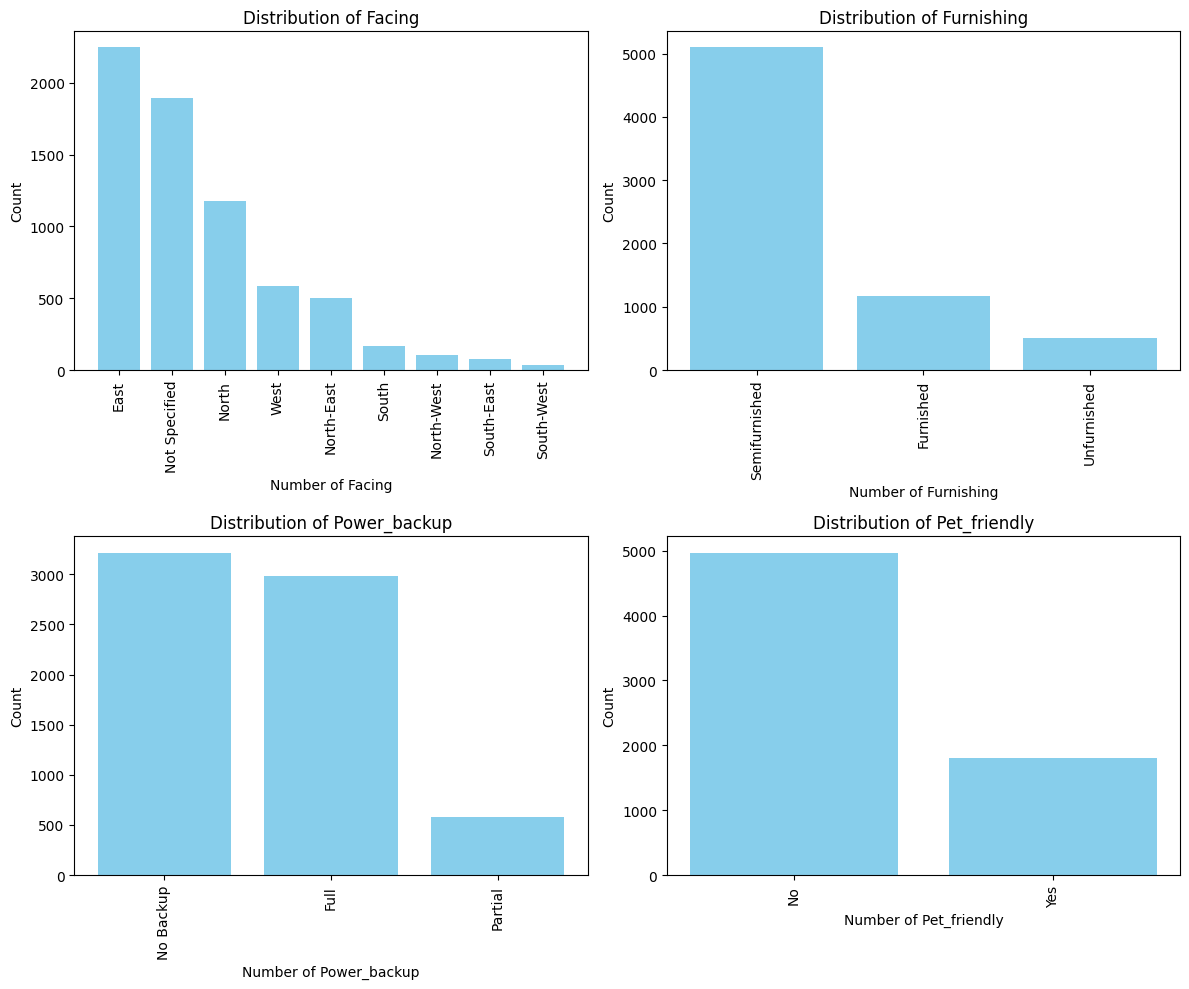

In [ ]:
Bar_Plot(['Facing', 'Furnishing', 'Power_backup', 'Pet_friendly'])

##
1. Distribution of Facing
- East-facing properties are the most common (*2247 listings*).
- *1893 properties* have "Not Specified" facing, indicating missing data.
- North-facing (*1175) and West-facing (583*) properties are also relatively common.
- Less common facings include:
  - North-East (*501*)
  - South (*167*)
  - South-East (*76*)
  - South-West (*32*)

---

## 2. Distribution of Furnishing
- Semi-furnished properties dominate (*5097 listings*).
- Furnished properties (*1177*) are less common.
- Unfurnished properties (*505*) are the least common.
- Most properties offer at least some level of furnishing.

---

## 3. Distribution of Power Backup
- A significant portion of properties (*3218) have **no power backup*.
- Full power backup is available in (*2986 properties*).
- Partial backup is the least common (*575 properties*).

---

## 4. Distribution of Pet-Friendly Properties
- Most properties (*4972) do **not allow pets*.
- Only (*1807 properties*) are pet-friendly.

---

## 🔑 Key Insights
- East-facing properties are the most preferred, while South and South-West facing are rare.
- Semi-furnished homes are the most common, while fully unfurnished homes are rare.
- Power backup is split, with many properties having either full or no backup, and very few with partial backup.
- Most properties do not allow pets, limiting options for pet owners.

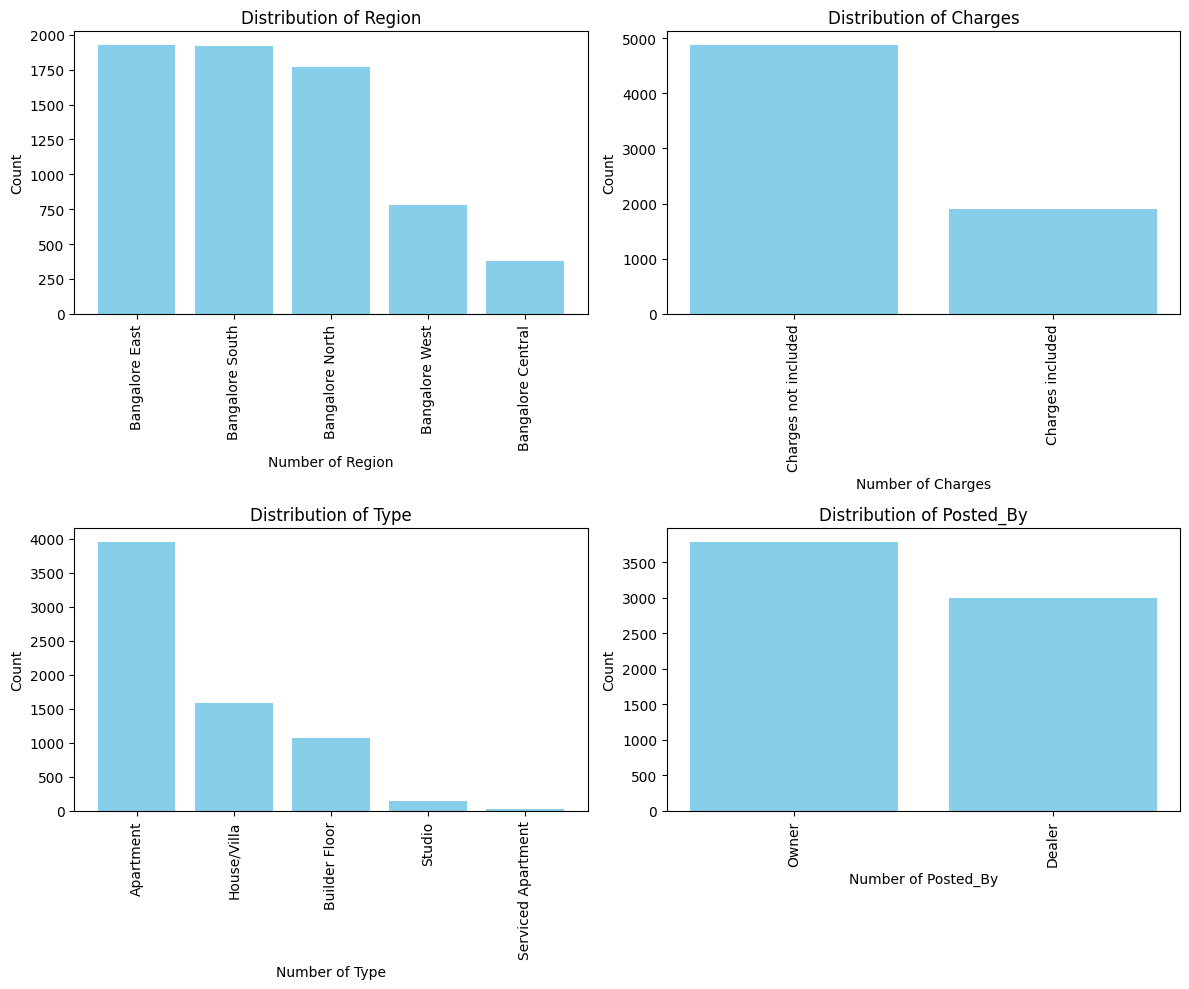

In [ ]:
Bar_Plot(['Region' , 'Charges' , 'Type' , 'Posted_By'])

# Rental Market Analysis – Bangalore

## 1. Regional Distribution of Listings
The highest concentration of rental listings is observed in **Bangalore East (1929)** and **Bangalore South (1927)**, followed closely by **Bangalore North (1767)**.  
In contrast, **Bangalore West (782)** and **Bangalore Central (379)** have significantly fewer listings.  

**Insight:** Rental activity is primarily concentrated in the East, South, and North regions of Bangalore.


## 2. Inclusion of Utility Charges (Water & Electricity)
A majority of properties (**4881**) do **not** include water and electricity charges in the rent, while only **1898** listings offer inclusive pricing.  

**Insight:** Most tenants are required to pay utility expenses separately, increasing the overall cost of renting.

## 3. Property Type Distribution
- **Apartments:** 3959 (Most common)
- **House/Villa:** 1579  
- **Builder Floor:** 1075  
- **Studio Apartments:** 138  
- **Serviced Apartments:** 28  

**Insight:** The market is heavily dominated by apartments, with limited availability of alternative housing types.

## 4. Listing Source (Posted By)
- **Owners:** 3788  
- **Dealers:** 2991  

**Insight:** The market offers a mix of direct owner listings and dealer-mediated options.

## Key Insights
- Rental listings are highly concentrated in East, South, and North Bangalore.  
- Utility charges are typically excluded from rent.  
- Apartments are the dominant housing type.  
- Listings are mostly posted by owners, with significant dealer participation.  

In [ ]:
df['Available_for_Family'].value_counts().index

Index([1, 0], dtype='int64', name='Available_for_Family')

In [ ]:
def Pie_Chart(columns, layout="row"):

    num_cols = len(columns)

    if layout == "row" and num_cols == 3:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1x3 layout
    elif layout == "grid" and num_cols <= 4:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 layout
        axes = axes.flatten()
    else:
        raise ValueError("Invalid layout type or number of columns. Use 'row' for 3 columns, 'grid' for up to 4.")

    for i, column in enumerate(columns):
        counts = df[column].value_counts()
        percentages = (counts / counts.sum()) * 100

        wedges, texts, autotexts = axes[i].pie(
            counts, labels=counts.index, autopct='%0.1f%%', startangle=90
        )

        axes[i].set_title(column)

        legend_labels = [f"{label}: {percent:.1f}%" for label, percent in zip(counts.index, percentages)]
        axes[i].legend(legend_labels, title=column, loc="upper left", bbox_to_anchor=(0.95, 0.75))

    plt.tight_layout()
    plt.show()

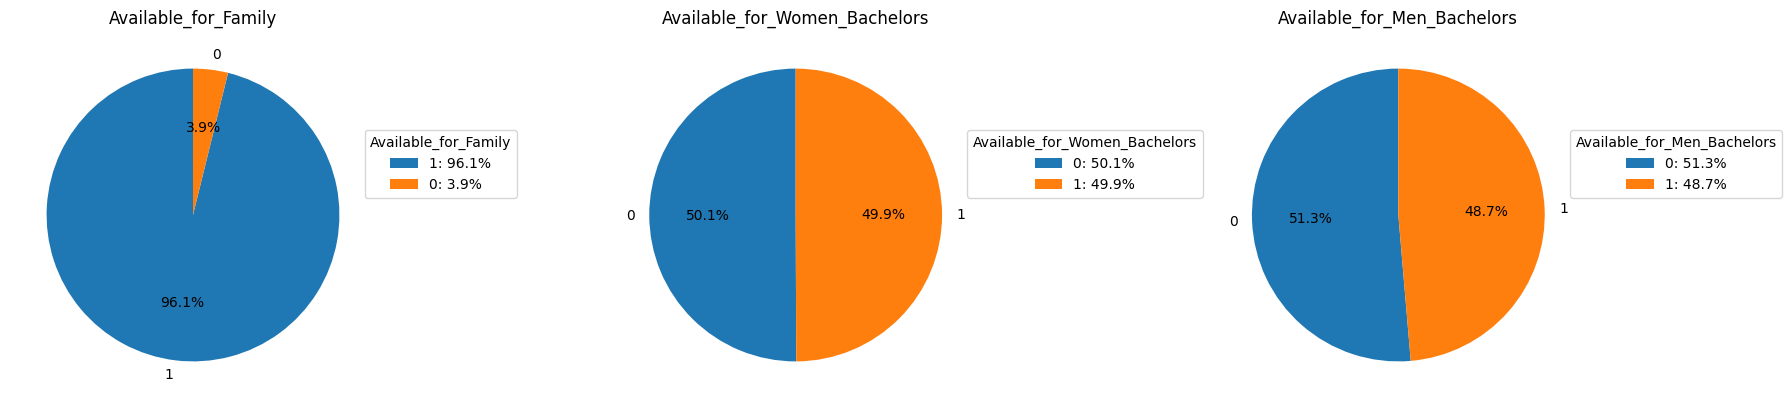

In [ ]:
Pie_Chart(['Available_for_Family', 'Available_for_Women_Bachelors', 'Available_for_Men_Bachelors'] , layout="row")

## Availability for Families
- **Available:** 96.1%  
- **Not Available:** 3.9%  

**Insight:** The majority of rental listings are family-friendly, making families the primary target group in the market.


## Availability for Women Bachelors
- **Allowed:** 49.9%  
- **Not Allowed:** 50.1%  

**Insight:** There is an almost equal split in availability, indicating moderate restrictions for women bachelors in the rental market.



## Availability for Men Bachelors
- **Allowed:** 48.7%  
- **Not Allowed:** 51.3%  

**Insight:** Similar to women bachelors, availability is nearly balanced, suggesting landlords maintain a cautious approach toward renting to bachelors.



## Key Insights
- Families have the highest acceptance rate, with most properties being family-friendly.  
- Bachelor tenants (both men and women) face noticeable restrictions.  
- Acceptance rates for men and women bachelors are nearly identical, indicating no strong bias toward either group.  

In [ ]:
df.columns

Index(['Property_ID', 'Region', 'Address', 'Locality', 'Bedroom', 'Bathroom',
       'Balcony', 'Additional_rooms', 'Area (sq.ft)', 'Facing', 'Furnishing',
       'Rating', 'Age', 'Covered_Parking', 'Open_Parking', 'Total_Parking',
       'Power_backup', 'Pet_friendly', 'Brokerage', 'Deposit', 'Maintenance',
       'Charges', 'Type', 'Available_for_Family',
       'Available_for_Women_Bachelors', 'Available_for_Men_Bachelors',
       'Posted_By', 'Total_Floors', 'Floor_For_Rent',
       'Hospitals_and_Clinics_Nearby', 'Bank_ATMs_Nearby',
       'Public_Places_Nearby', 'Education_Centre_Nearby',
       'Transportation_Depots_Nearby', 'Rent'],
      dtype='object')

In [ ]:
def univariate_analysis(column):
    print(f"\n{'='*30} Univariate Analysis: {column} {'='*30}\n")

    sns.set_style("whitegrid")

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    sns.histplot(df[column], bins=30, kde=True, ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title(f"Histogram & KDE of {column}", fontsize=14)
    axes[0].set_xlabel(column, fontsize=12)
    axes[0].set_ylabel("Frequency", fontsize=12)

    sns.boxplot(x=df[column], ax=axes[1], color='#e74c3c', width=0.4)
    sns.stripplot(x=df[column], ax=axes[1], color='black', size=3, jitter=True, alpha=0.5)
    axes[1].set_title(f"Boxplot of {column}", fontsize=14)
    axes[1].set_xlabel(column, fontsize=12)

    sns.violinplot(x=df[column], ax=axes[2], inner="quartile", color='#2ecc71')
    axes[2].set_title(f"Violin Plot of {column}", fontsize=14)
    axes[2].set_xlabel(column, fontsize=12)

    plt.tight_layout()
    plt.show()


============================== Univariate Analysis: Area (sq.ft) ==============================



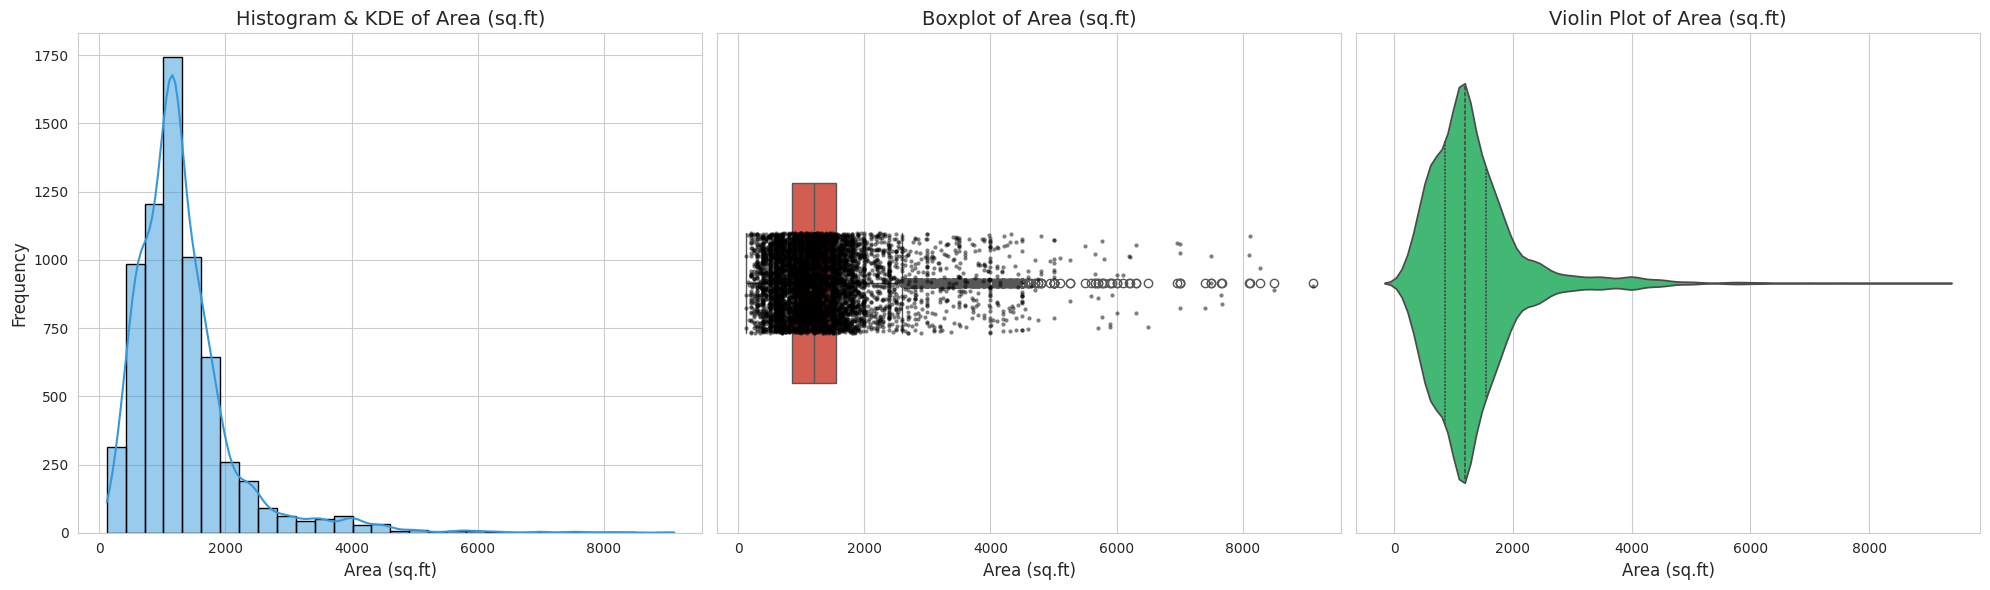

In [ ]:
univariate_analysis('Area (sq.ft)')

## Insights from the Univariate Analysis of Area (sq. ft.)

### Histogram & KDE Plot
The distribution of area is **right-skewed**, meaning most properties have a smaller area (e.g., below 2000 sq. ft.), but a few very large properties create a long tail.  

- The highest frequency of properties falls between **1000 to 1500 sq. ft.**  
- The KDE curve shows a peak around **1200–1300 sq. ft.**  

**Insight:** Most properties are mid-sized, with a small number of significantly larger homes.


### Boxplot
- The **median area** is below **2000 sq. ft.**  
- There are several **outliers beyond 4000 sq. ft.**, representing large or luxury properties.  
- The **interquartile range (IQR)** is compact, indicating most properties fall within a limited size range.  

**Insight:** While most properties are similar in size, a few large properties significantly exceed the average.


### Violin Plot
- The widest section shows a concentration between **1000 to 2000 sq. ft.**  
- The distribution becomes narrower at higher values, confirming that larger properties are rare.  
- The density suggests a **bimodal-like pattern**, indicating two possible clusters (e.g., apartments vs. villas).  

**Insight:** Property sizes are mainly concentrated in a common range, with indications of two dominant housing categories.


============================== Univariate Analysis: Maintenance ==============================



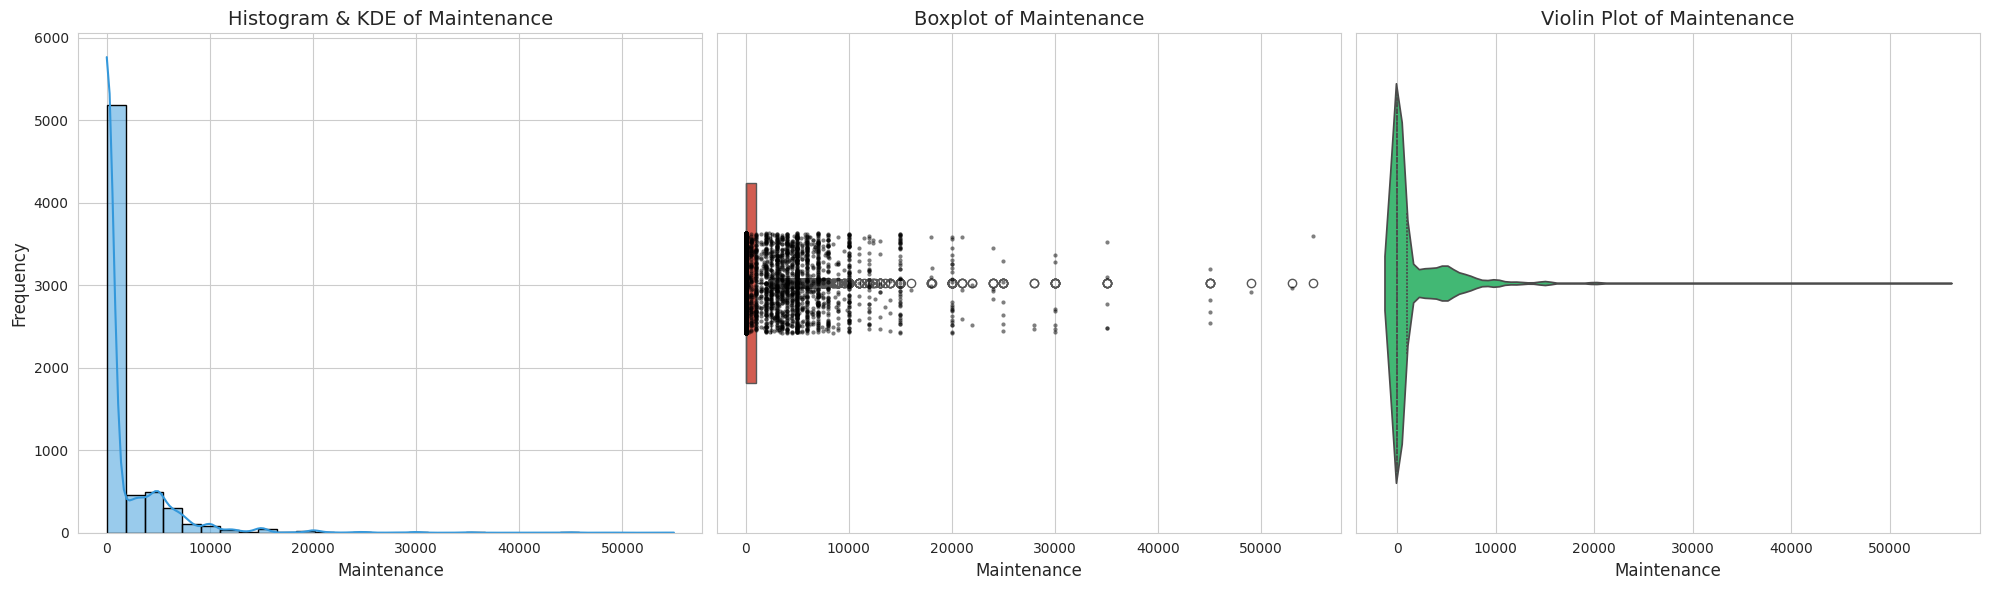

In [ ]:
univariate_analysis('Maintenance')

## Insights from the Univariate Analysis of Maintenance

### Histogram & KDE Plot
- The distribution of maintenance charges is **highly right-skewed**, meaning most properties have low maintenance costs.  
- A majority of values are concentrated near **zero**, suggesting that many properties have low or no maintenance fees.  
- A long tail extends towards higher values, indicating some properties have very high maintenance costs, but these are rare.  

**Insight:** Low maintenance fees are common, while very high fees are outliers.



### Boxplot
- The **median maintenance value** is low, confirming that most properties have affordable maintenance fees.  
- Many **outliers** exist, with some properties exceeding **50,000** in maintenance costs.  
- The **IQR is narrow**, meaning most values fall within a small range, but high-end properties create a long spread.  

**Insight:** Most properties have moderate maintenance, while a few luxury properties have extremely high fees.



### Violin Plot
- Highest density is concentrated at **low maintenance values**, indicating low fees are common.  
- The long right tail confirms a few properties have exceptionally high costs, acting as outliers.  
- The wider spread at the lower end reinforces that low values are much more frequent.  

**Insight:** Maintenance costs are mostly low, with occasional extreme values creating a right-skewed distribution.


### Key Takeaways
- Most properties have low maintenance fees, making them attractive to tenants.  
- A few high-end properties have extremely high maintenance costs.  
- The dataset is **highly right-skewed**, with values concentrated at the lower end.

In [ ]:
import sqlite3
conn=sqlite3.connect(':memory:')
df.to_sql('df',conn,index=False)
group=pd.read_sql_query('''select * from df
group by "Locality"
limit 2''',conn)

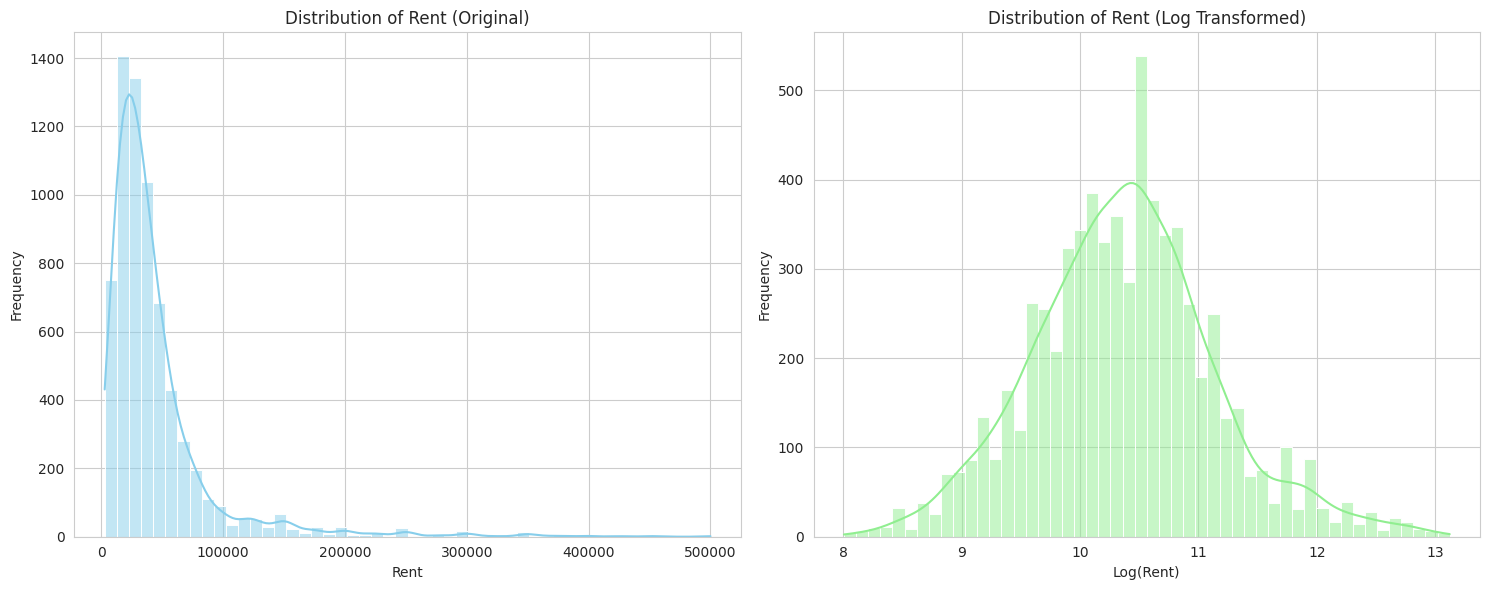

In [ ]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['Rent'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Rent (Original)')
plt.xlabel('Rent')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['Rent']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Rent (Log Transformed)')
plt.xlabel('Log(Rent)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Insights from Rent Distribution Analysis

### Skewed Distribution of Rent (Original Rent Values)
- The rent distribution is right-skewed, meaning most properties have relatively lower rents, while a few have extremely high values.  
- A majority of rental values are below ₹50,000, but a long tail extends toward ₹200,000+, indicating luxury rentals.  
- There are outliers with very high rents, which can distort average-based analysis.  

Insight: Most rentals are affordable, but a small number of high-end properties affect the overall distribution.


### Normalized Rent Distribution (Log Transformed)
- Applying a log transformation makes the rent distribution approximately normal (bell-shaped).  
- This reduces the impact of outliers and makes the data more suitable for statistical modeling.  
- The log scale ensures properties with high and low rents are more evenly represented, improving interpretability.  

Insight: Log transformation helps in handling extreme rent values and provides a clearer view of the overall rental market.

<Axes: ylabel='Count'>

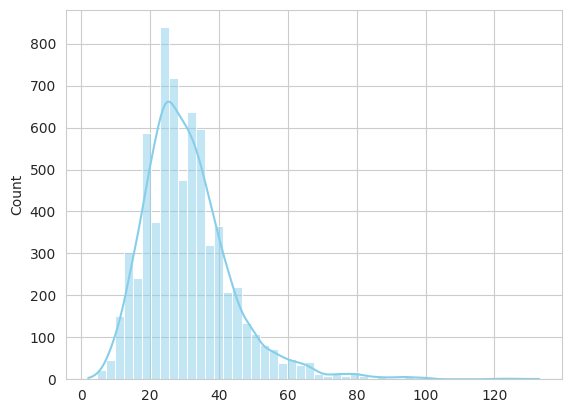

In [ ]:
Rent_per_sqft = np.ceil(df['Rent'] / df['Area (sq.ft)'])
sns.histplot(Rent_per_sqft, bins=50, color='skyblue', kde=True)


## Insights from Rent per Square Foot Distribution

### Right-Skewed Distribution
- The histogram shows a positively skewed (right-skewed) distribution, indicating most properties have lower rent per square foot, while a few have significantly higher values.  
- This suggests the presence of premium or luxury properties driving the long tail.  

Insight: Most rentals are affordable per square foot, with a few high-end listings creating skewness.



### Most Common Rent per Sq. Ft. Range
- The peak (mode) of the distribution is around ₹20-30 per sq. ft., meaning most rental listings fall within this range.  
- There is a gradual decline beyond ₹40 per sq. ft., with fewer properties in the high-rent segment.  

Insight: Typical rental rates per square foot are concentrated in the ₹20-30 range.


### Outliers and High-Value Listings
- Some properties have rent per sq. ft. exceeding ₹100, indicating luxury apartments or high-demand areas.  
- These extreme values suggest potential outliers or properties in premium localities that differ significantly from the majority.  

Insight: While most rentals are moderate, a few premium listings significantly exceed typical rates.

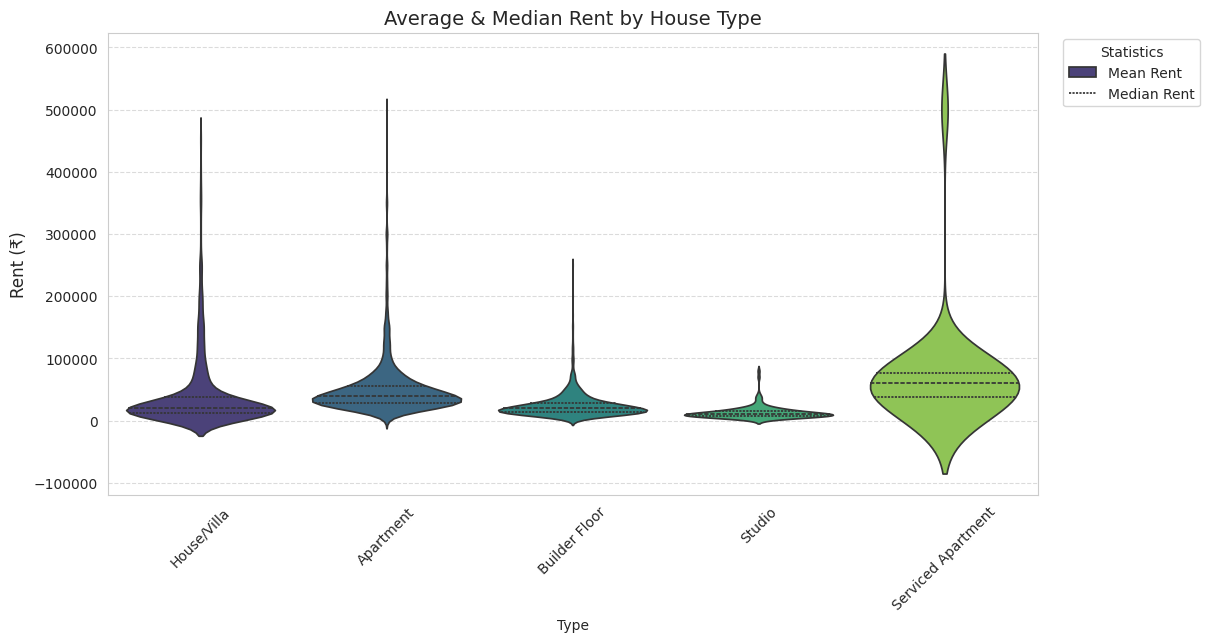

In [ ]:

plt.figure(figsize=(12, 6))

rent_stats = df.groupby('Type')['Rent'].agg(['mean', 'median']).round(0)
sns.violinplot(x='Type', y='Rent', data=df, palette='viridis', inner='quartile')
plt.ylabel("Rent (₹)", fontsize=12)
plt.title("Average & Median Rent by House Type", fontsize=14)
plt.xticks(rotation=45)
plt.legend(["Mean Rent", "Median Rent"], title="Statistics", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Insights from Violin Plot: Rent Distribution by House Type

### Density of Rent Prices
- House/Villa and Apartment show high density in the ₹20,000–₹50,000 range, with extreme outliers extending beyond ₹500,000.  
- Serviced Apartments have a wider rent distribution, with dense clusters around ₹50,000–₹100,000, confirming their premium nature.  

Insight: Most properties fall in mid-range rents, while serviced apartments and some houses represent higher-end rentals.


### Comparison of Median and Distribution
- The median rent for Serviced Apartments is significantly higher than other types.  
- Studios show the narrowest distribution, with rents concentrated around ₹10,000–₹20,000, indicating affordability and consistency.  

Insight: Rent varies widely by property type, with studios being affordable and serviced apartments being premium.



### Asymmetrical Distributions
- Builder Floors and Serviced Apartments are slightly skewed, indicating some higher-end properties pushing the upper rent boundary.  
- House/Villa and Apartment distributions are more symmetrical but elongated due to a few high-value listings.  

Insight: Skewness highlights the presence of luxury properties in certain house types.


### Presence of Outliers
- All house types, especially House/Villa and Serviced Apartments, have significant outliers, likely representing luxury properties.  

Insight: Outliers indicate that a few high-end properties significantly exceed typical rent ranges for their type.

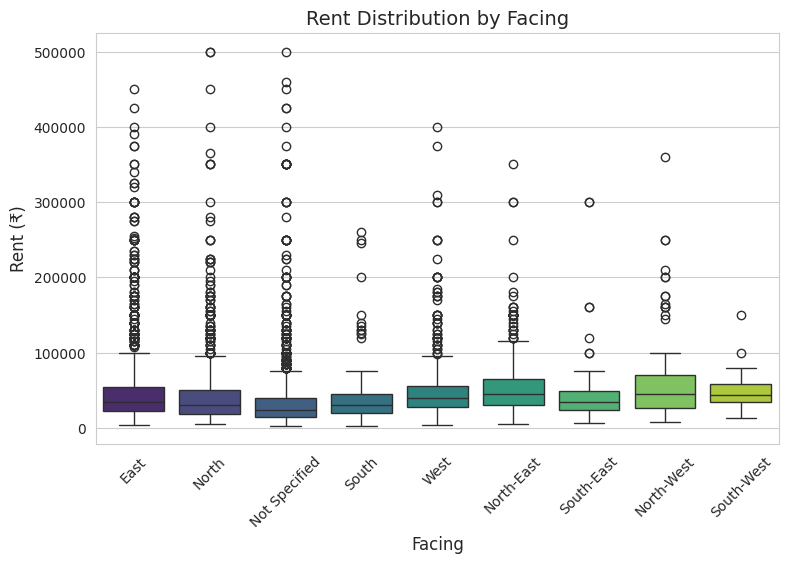

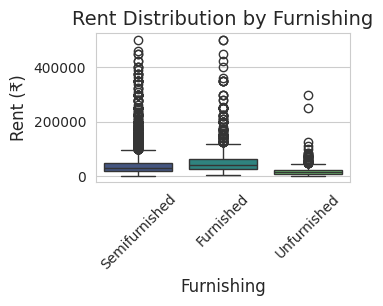

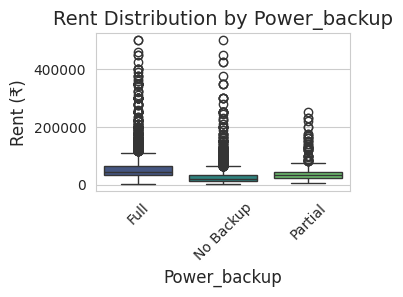

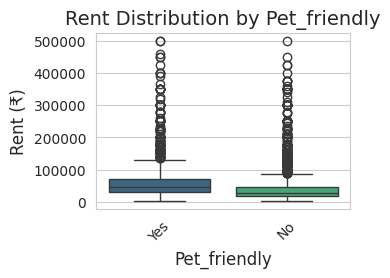

In [ ]:
categorical_features = ['Facing', 'Furnishing', 'Power_backup', 'Pet_friendly']
plt.figure(figsize=(15, 10))

for i, feature in enumerate(categorical_features, 1):
  plt.subplot(2, 2, i)
  sns.boxplot(x=df[feature], y=df['Rent'], palette='viridis')
  plt.xticks(rotation=45)
  plt.xlabel(feature, fontsize=12)
  plt.ylabel("Rent (₹)", fontsize=12)
  plt.title(f"Rent Distribution by {feature}", fontsize=14)


  plt.tight_layout()
  plt.show()

In [ ]:
def categorical_boxplots(df):

    categorical_features = ['Facing', 'Furnishing', 'Power_backup', 'Pet_friendly']
    plt.figure(figsize=(15, 10))

    for i, feature in enumerate(categorical_features, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[feature], y=df['Rent'], palette='viridis')
        plt.xticks(rotation=45)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel("Rent (₹)", fontsize=12)
        plt.title(f"Rent Distribution by {feature}", fontsize=14)

    plt.tight_layout()
    plt.show()



In [ ]:
categorical_boxplots(df)